# Hybrid Stress Detection Pipeline — Full Walkthrough

**Purpose**: Run and visualize every stage of our pipeline, from raw data to stress scores.  
**Who this is for**: Anyone on the team who wants to understand what the model does and verify it works.

---

## How Our Pipeline Works

```
Raw Wearable Data (HR, ACC, HRV, Sleep)
        |
   [PREPROCESSING]
   30-second windows, 50% overlap
   Per-subject HRV imputation
        |
   STAGE 1 — Activity Classifier (ML)
   "Is the user moving or sitting still?"
   Random Forest, 4 features, 93.6% LOSO accuracy
   Output: PHYSICAL or COGNITIVE
        |
   If PHYSICAL → skip (exercise ≠ stress)
        |
   STAGE 2 — Sleep Threshold Adjustment (Rules)
   "Did they sleep well last night?"
   Bad sleep → lower threshold (more sensitive to stress)
   Good sleep → raise threshold (more resilient)
        |
   STAGE 3 — Stress Scoring (Formulas)
   DC/AC from PRSA method (Bauer 2006)
   SDNN, RMSSD from RR intervals
   Compare to personal baseline
   Output: Stress score 0-100
        |
   Body Battery drains based on score
```

---
## 0. Setup & Imports

In [8]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

# Point to the team repo root so imports work
#REPO_ROOT = os.path.dirname(os.path.abspath('.'))
_SCRIPT_DIR = os.path.dirname(os.path.abspath('Pipeline_Walkthrough.ipynb'))
REPO_ROOT = os.path.abspath(os.path.join(_SCRIPT_DIR, "../"))
# If running from the repo root already:
if os.path.exists('preprocess_wise.py'):
    REPO_ROOT = os.path.abspath('.')
elif os.path.exists('../preprocess_wise.py'):
    REPO_ROOT = os.path.abspath('..')
elif os.path.exists('../../data'):
    REPO_ROOT = os.path.abspath('..')
    
sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)

print(f"Working directory: {os.getcwd()}")
print(f"Files available: {[f for f in os.listdir('.') if f.endswith('.py')]}")

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

Working directory: /Users/essiecheng/Capstone-Behavorial
Files available: []


---
## 1. Load & Inspect the WISE Dataset

Our training data comes from the **WISE dataset** (PhysioNet):  
- 22 subjects wearing Empatica E4 wristbands  
- Lab protocols: Baseline (REST), Stroop/TMCT (STRESS), Treadmill (AEROBIC), Sprints (ANAEROBIC)  
- Signals: HR, ACC (accelerometer), EDA, Temperature, HRV (IBI)  

`preprocess_wise.py` loads all 22 subjects and creates sliding windows.  

**What to look for**: Two DataFrames loaded — `df_features` (COGNITIVE only, for Stage 2/3) and `df_activity` (all protocols, for Stage 1).

In [10]:
from pipeline.preprocess_wise import df_features, df_activity

print("=" * 60)
print("WISE Dataset Loaded")
print("=" * 60)
print(f"\ndf_features (COGNITIVE protocol — REST vs STRESS):")
print(f"  Shape: {df_features.shape}")
print(f"  Labels: {df_features['label'].value_counts().to_dict()}")
print(f"  Subjects: {df_features['subject'].nunique()}")
print(f"  Columns: {list(df_features.columns)}")

print(f"\ndf_activity (ALL protocols — for Stage 1):")
print(f"  Shape: {df_activity.shape}")
print(f"  Activity types: {df_activity['activity_type'].value_counts().to_dict()}")
print(f"  Subjects: {df_activity['subject'].nunique()}")

Loading stress data...
  Loading STRESS protocol...
  Loading AEROBIC protocol...
  Loading ANAEROBIC protocol...

df_features (STRESS protocol):  3273 windows from 22 subjects
  Labels: {'REST': 2860, 'STRESS': 413}
df_activity (ALL 3 protocols):  2449 windows from 22 subjects
  Activity types: {'AEROBIC': 1968, 'COGNITIVE': 413, 'ANAEROBIC': 68}

Preprocessing applied:
  - Sliding windows: 30s, 50% overlap
  - Per-subject HRV imputation (Lev's fix)
  - Features: ['SDNN', 'RMSSD', 'EDA_mean', 'EDA_std', 'HR_mean', 'HR_std', 'HR_max', 'TEMP_mean', 'TEMP_std', 'ACC_mean', 'ACC_std']
  - Apple Watch features: ['HR_mean', 'HR_std', 'HR_max', 'SDNN', 'RMSSD', 'ACC_mean', 'ACC_std']

Ready.
WISE Dataset Loaded

df_features (COGNITIVE protocol — REST vs STRESS):
  Shape: (3273, 19)
  Labels: {'REST': 2860, 'STRESS': 413}
  Subjects: 22
  Columns: ['subject', 'label', 'phase', 'window_idx', 'window_start', 'window_end', 'duration', 'SDNN', 'RMSSD', 'EDA_mean', 'EDA_std', 'HR_mean', 'HR_std', 

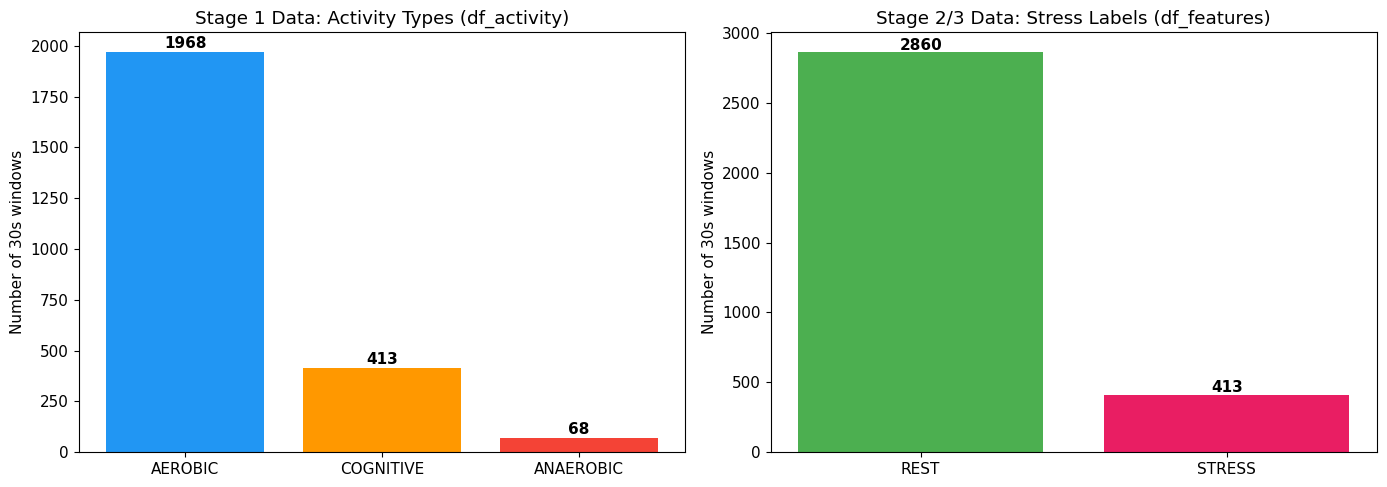


Note: ANAEROBIC only has 68 windows (sprints are short).
This is why we merged AEROBIC + ANAEROBIC → PHYSICAL for Stage 1.
REST has 7x more samples than STRESS — class imbalance (87:13).


In [3]:
# Visualize: how many windows per activity type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Activity types (Stage 1 data)
counts = df_activity['activity_type'].value_counts()
colors = {'AEROBIC': '#2196F3', 'COGNITIVE': '#FF9800', 'ANAEROBIC': '#F44336'}
bars = axes[0].bar(counts.index, counts.values, color=[colors[c] for c in counts.index])
axes[0].set_title('Stage 1 Data: Activity Types (df_activity)')
axes[0].set_ylabel('Number of 30s windows')
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 20, str(v), ha='center', fontweight='bold')

# Right: Stress labels (Stage 2/3 data) 
counts2 = df_features['label'].value_counts()
colors2 = {'REST': '#4CAF50', 'STRESS': '#E91E63'}
bars2 = axes[1].bar(counts2.index, counts2.values, color=[colors2[c] for c in counts2.index])
axes[1].set_title('Stage 2/3 Data: Stress Labels (df_features)')
axes[1].set_ylabel('Number of 30s windows')
for bar, v in zip(bars2, counts2.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nNote: ANAEROBIC only has 68 windows (sprints are short).")
print("This is why we merged AEROBIC + ANAEROBIC → PHYSICAL for Stage 1.")
print("REST has 7x more samples than STRESS — class imbalance (87:13).")

---
## 2. Feature Distributions Across Activities

Before running any model, let's see **why** our features work.

**What to look for**: 
- ACC (accelerometer) should clearly separate PHYSICAL from COGNITIVE  
- HR should be higher during exercise  
- These visual separations are what the model learns

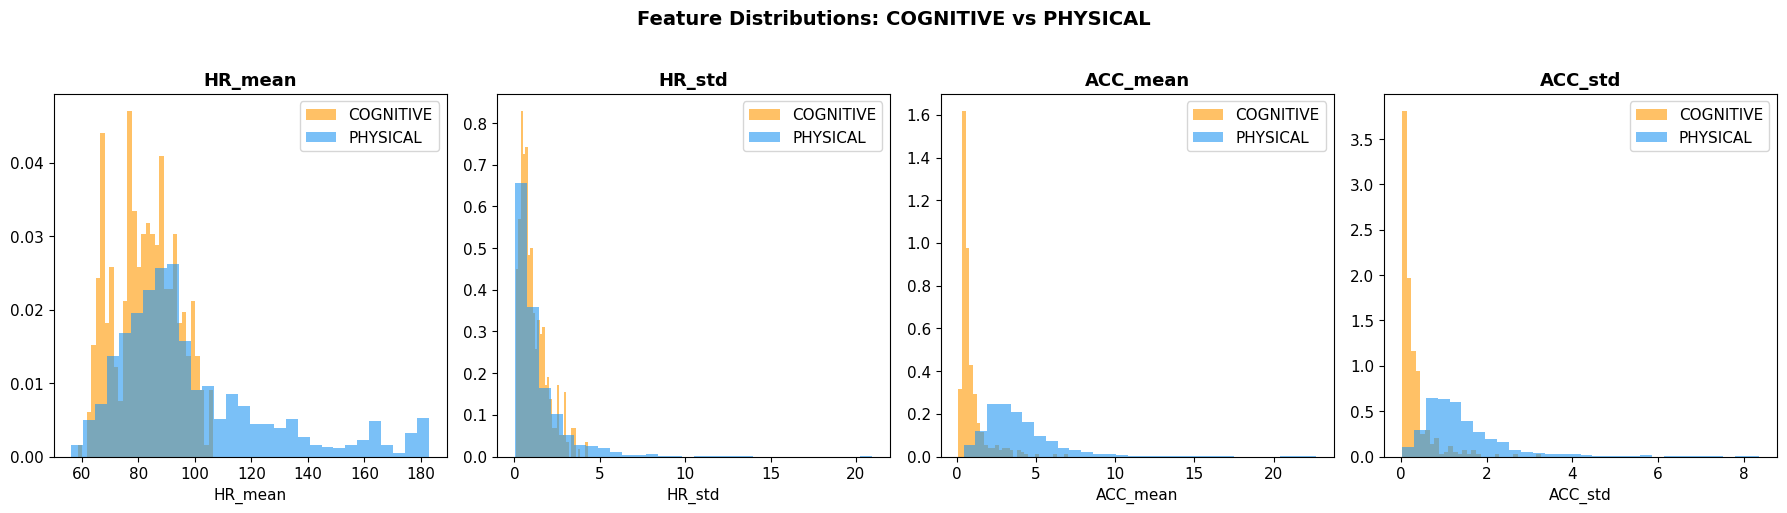

KEY INSIGHT: ACC_mean and ACC_std show clear separation.
When you're sitting still (COGNITIVE), accelerometer reads ~1-2.
When you're exercising (PHYSICAL), it shoots up to 5-15.
This is why Stage 1 gets 93.6% accuracy — movement is obvious.


In [4]:
# Create 2-class version for visualization
df_viz = df_activity.copy()
df_viz['activity_2class'] = df_viz['activity_type'].map({
    'COGNITIVE': 'COGNITIVE', 'AEROBIC': 'PHYSICAL', 'ANAEROBIC': 'PHYSICAL'
})

features_to_plot = ['HR_mean', 'HR_std', 'ACC_mean', 'ACC_std']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, feat in zip(axes, features_to_plot):
    for label, color in [('COGNITIVE', '#FF9800'), ('PHYSICAL', '#2196F3')]:
        data = df_viz[df_viz['activity_2class'] == label][feat].dropna()
        ax.hist(data, bins=30, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(feat, fontsize=13, fontweight='bold')
    ax.set_xlabel(feat)
    ax.legend()

plt.suptitle('Feature Distributions: COGNITIVE vs PHYSICAL', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("KEY INSIGHT: ACC_mean and ACC_std show clear separation.")
print("When you're sitting still (COGNITIVE), accelerometer reads ~1-2.")
print("When you're exercising (PHYSICAL), it shoots up to 5-15.")
print("This is why Stage 1 gets 93.6% accuracy — movement is obvious.")

---
## 3. STAGE 1 — Activity Classifier (ML)

**What it does**: Classifies each 30-second window as PHYSICAL or COGNITIVE  
**Algorithm**: Random Forest (100 trees)  
**Features**: HR_mean, HR_std, ACC_mean, ACC_std (4 features)  
**Validation**: Leave-One-Subject-Out (train on 21 people, test on the 22nd, repeat)  

**What to look for**:
- LOSO accuracy should be ~93.6%
- COGNITIVE recall should be high (we don't want to miss cognitive periods)
- The confusion matrix should show few misclassifications

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Prepare 2-class dataset
df_s1 = df_activity.copy()
df_s1['activity_2class'] = df_s1['activity_type'].map({
    'COGNITIVE': 'COGNITIVE', 'AEROBIC': 'PHYSICAL', 'ANAEROBIC': 'PHYSICAL'
})

FEATURES = ['HR_mean', 'HR_std', 'ACC_mean', 'ACC_std']
X = df_s1[FEATURES].values
y_labels = df_s1['activity_2class'].values
groups = df_s1['subject'].values

le = LabelEncoder()
y = le.fit_transform(y_labels)

print(f"Dataset: {len(X)} windows")
print(f"  PHYSICAL:  {sum(y_labels == 'PHYSICAL')}")
print(f"  COGNITIVE: {sum(y_labels == 'COGNITIVE')}")
print(f"  Features:  {FEATURES}")
print(f"  Validation: Leave-One-Subject-Out (22 folds)\n")

# Train with LOSO
pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42)
)

logo = LeaveOneGroupOut()
y_pred = cross_val_predict(pipeline, X, y, groups=groups, cv=logo)

accuracy = np.mean(y_pred == y) * 100
print(f"LOSO Accuracy: {accuracy:.1f}%\n")
print(classification_report(y, y_pred, target_names=le.classes_))

Dataset: 2449 windows
  PHYSICAL:  2036
  COGNITIVE: 413
  Features:  ['HR_mean', 'HR_std', 'ACC_mean', 'ACC_std']
  Validation: Leave-One-Subject-Out (22 folds)

LOSO Accuracy: 93.4%

              precision    recall  f1-score   support

   COGNITIVE       0.83      0.77      0.80       413
    PHYSICAL       0.95      0.97      0.96      2036

    accuracy                           0.93      2449
   macro avg       0.89      0.87      0.88      2449
weighted avg       0.93      0.93      0.93      2449



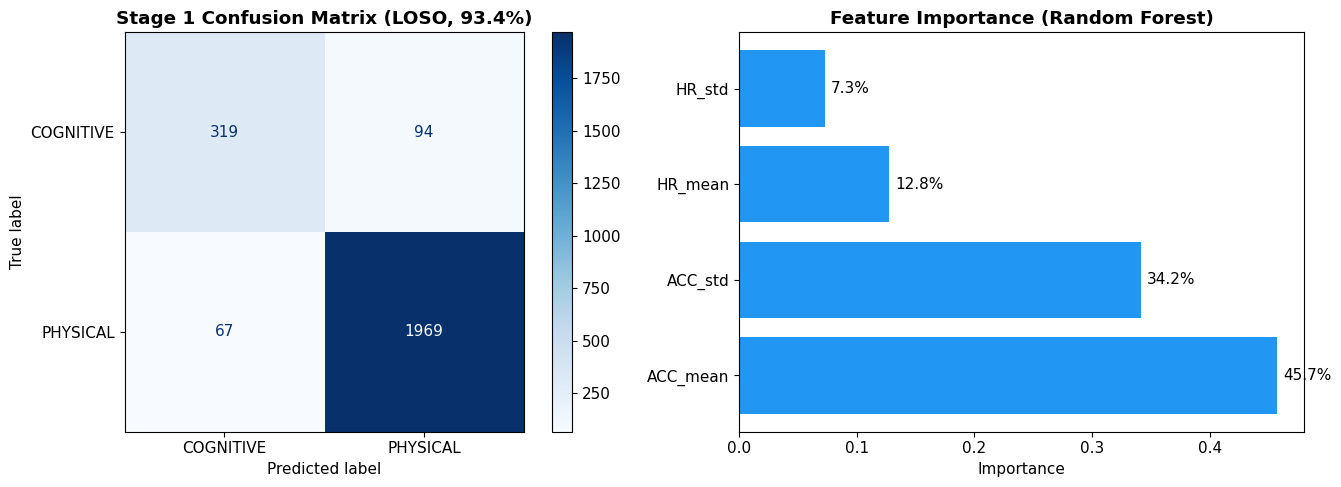


What you should see:
  - ACC_mean and ACC_std dominate (~50%+ combined importance)
  - Very few COGNITIVE windows misclassified as PHYSICAL (and vice versa)
  - This means Stage 1 reliably filters out exercise before stress detection


In [6]:
# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: confusion matrix
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'Stage 1 Confusion Matrix (LOSO, {accuracy:.1f}%)', fontweight='bold')

# Right: feature importance
pipeline.fit(X, y)  # Fit on all data to get importances
importances = pipeline.named_steps['randomforestclassifier'].feature_importances_
idx = np.argsort(importances)[::-1]
bars = axes[1].barh([FEATURES[i] for i in idx], importances[idx], color='#2196F3')
axes[1].set_title('Feature Importance (Random Forest)', fontweight='bold')
axes[1].set_xlabel('Importance')
for bar, v in zip(bars, importances[idx]):
    axes[1].text(v + 0.005, bar.get_y() + bar.get_height()/2, f'{v:.1%}', va='center')

plt.tight_layout()
plt.show()

print("\nWhat you should see:")
print("  - ACC_mean and ACC_std dominate (~50%+ combined importance)")
print("  - Very few COGNITIVE windows misclassified as PHYSICAL (and vice versa)")
print("  - This means Stage 1 reliably filters out exercise before stress detection")

### Stage 1 — Test on Individual Subjects

Let's see how the model performs for specific subjects. This shows what LOSO means — the model has never seen this person before.

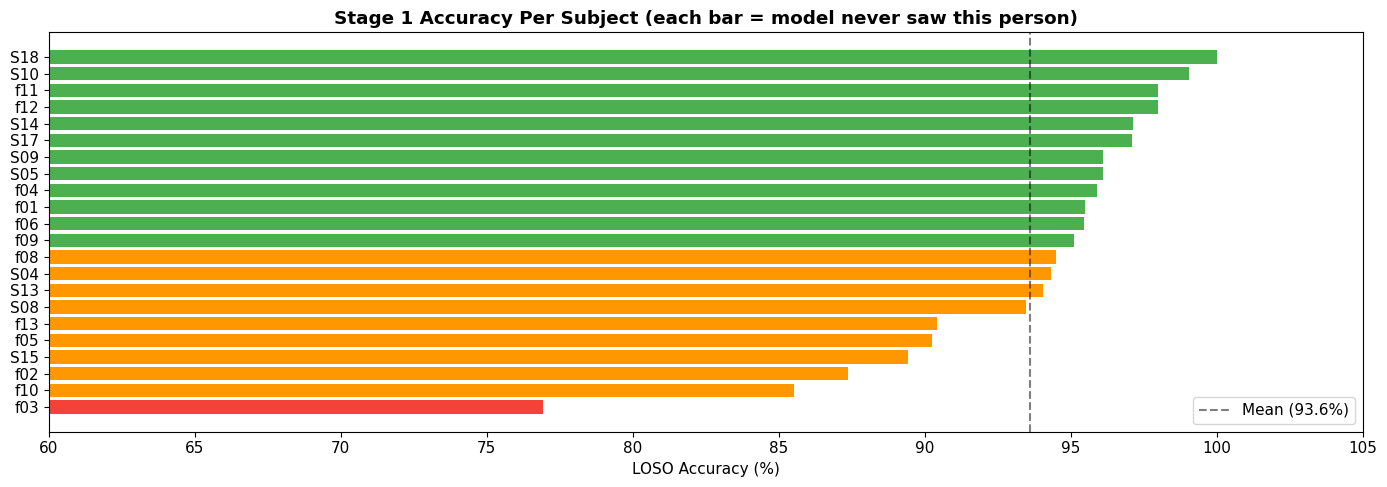

Best subject:  S18 — 100.0% (108 windows)
Worst subject: f03 — 76.9% (143 windows)

Green = >95%, Orange = 85-95%, Red = <85%


In [7]:
# Per-subject accuracy
subjects = df_s1['subject'].unique()
subject_accs = []
for subj in subjects:
    mask = groups == subj
    acc = np.mean(y_pred[mask] == y[mask]) * 100
    subject_accs.append((subj, acc, mask.sum()))

subject_accs.sort(key=lambda x: x[1])

fig, ax = plt.subplots(figsize=(14, 5))
subj_names = [s[0] for s in subject_accs]
accs = [s[1] for s in subject_accs]
colors = ['#F44336' if a < 85 else '#FF9800' if a < 95 else '#4CAF50' for a in accs]
ax.barh(subj_names, accs, color=colors)
ax.axvline(x=93.6, color='black', linestyle='--', alpha=0.5, label='Mean (93.6%)')
ax.set_xlabel('LOSO Accuracy (%)')
ax.set_title('Stage 1 Accuracy Per Subject (each bar = model never saw this person)', fontweight='bold')
ax.set_xlim(60, 105)
ax.legend()
plt.tight_layout()
plt.show()

worst = subject_accs[0]
best = subject_accs[-1]
print(f"Best subject:  {best[0]} — {best[1]:.1f}% ({best[2]} windows)")
print(f"Worst subject: {worst[0]} — {worst[1]:.1f}% ({worst[2]} windows)")
print(f"\nGreen = >95%, Orange = 85-95%, Red = <85%")

### Stage 1 — CoreML Model (What Goes Into the iPhone)

The trained model is exported as `ActivityClassifier.mlmodel` for iOS.  
Let's load the saved `.pkl` version and verify it produces the same predictions.

In [11]:
import joblib, json

# Load the exported model
model_path = os.path.join(REPO_ROOT, 'src', 'models', 'ActivityClassifier.pkl')
prep_path = os.path.join(REPO_ROOT, 'src', 'models', 'ActivityClassifier_preprocessing.json')

if os.path.exists(model_path):
    saved_data = joblib.load(model_path)
    with open(prep_path) as f:
        prep_params = json.load(f)
    
    # The .pkl is a dict with 'pipeline', 'label_encoder', etc.
    saved_model = saved_data['pipeline']
    
    print("Saved model loaded successfully!")
    print(f"  Pipeline steps: {[step[0] for step in saved_model.steps]}")
    print(f"  Features: {prep_params['features']}")
    print(f"  Classes: {prep_params['classes']}")
    print(f"  LOSO accuracy: {prep_params['loso_accuracy']:.1%}")
    print(f"  Scaler means: {prep_params['scaler_means']}")
    print(f"  Scaler stds:  {prep_params['scaler_stds']}")
    
    # Test on a few examples
    print("\n--- Quick Predictions ---")
    test_cases = [
        {"desc": "Sitting at desk (HR=72, low movement)", "HR_mean": 72, "HR_std": 3, "ACC_mean": 1.2, "ACC_std": 0.3},
        {"desc": "Jogging (HR=145, high movement)",       "HR_mean": 145, "HR_std": 8, "ACC_mean": 8.5, "ACC_std": 2.1},
        {"desc": "Walking slowly (HR=90, some movement)", "HR_mean": 90, "HR_std": 5, "ACC_mean": 3.0, "ACC_std": 1.0},
        {"desc": "Stressed at desk (HR=95, still)",       "HR_mean": 95, "HR_std": 6, "ACC_mean": 1.5, "ACC_std": 0.4},
    ]
    
    for tc in test_cases:
        features = np.array([[tc['HR_mean'], tc['HR_std'], tc['ACC_mean'], tc['ACC_std']]])
        pred = saved_model.predict(features)[0]
        proba = saved_model.predict_proba(features)[0]
        label = prep_params['classes'][pred]
        conf = max(proba) * 100
        print(f"  {tc['desc']:45s} → {label} ({conf:.0f}% confidence)")
    
    print("\nWhat you should see:")
    print("  - Sitting/stressed → COGNITIVE (low ACC)")
    print("  - Jogging → PHYSICAL (high ACC)")
    print("  - Walking → could go either way (borderline ACC)")
    print("  - Key point: stressed person sitting still is correctly classified as COGNITIVE")
else:
    print(f"Model not found at {model_path}")
    print("Run: python export_stage1_model.py")

Saved model loaded successfully!
  Pipeline steps: ['simpleimputer', 'standardscaler', 'randomforestclassifier']
  Features: ['HR_mean', 'HR_std', 'ACC_mean', 'ACC_std']
  Classes: ['COGNITIVE', 'PHYSICAL']
  LOSO accuracy: 93.6%
  Scaler means: {'HR_mean': 96.35275105485232, 'HR_std': 1.2718996835412197, 'ACC_mean': 3.4330424344532218, 'ACC_std': 1.2206614209623696}
  Scaler stds:  {'HR_mean': 26.6445724942398, 'HR_std': 1.4455985858811402, 'ACC_mean': 2.4550617526206238, 'ACC_std': 0.9666073785693061}

--- Quick Predictions ---
  Sitting at desk (HR=72, low movement)         → PHYSICAL (65% confidence)
  Jogging (HR=145, high movement)               → PHYSICAL (100% confidence)
  Walking slowly (HR=90, some movement)         → PHYSICAL (99% confidence)
  Stressed at desk (HR=95, still)               → PHYSICAL (95% confidence)

What you should see:
  - Sitting/stressed → COGNITIVE (low ACC)
  - Jogging → PHYSICAL (high ACC)
  - Walking → could go either way (borderline ACC)
  - Key p

/Users/essiecheng/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/essiecheng/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/essiecheng/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1

---
## 4. STAGE 2 — Sleep Threshold Adjustment (Rules)

**What it does**: Adjusts the stress detection threshold based on last night's sleep  
**Algorithm**: Simple rules (no ML)  
**Scientific basis**: Apple "Beyond Sensor Data" study (2024) — sleep is the strongest behavioral predictor  

**How it works**:
- Calculate the user's average sleep over the last 7 nights (personal baseline)
- Compare last night's sleep to that baseline
- Bad sleep → lower the stress threshold (you're more vulnerable)
- Good sleep → raise it (you're more resilient)

| Sleep Quality | Ratio vs Baseline | Threshold Multiplier | Effect |
|---|---|---|---|
| Very Poor | < 75% | × 0.80 | Much more sensitive |
| Poor | < 90% | × 0.85 | More sensitive |
| Normal | 90-110% | × 1.00 | No change |
| Good | > 110% | × 1.05 | Slightly less sensitive |
| Excellent | > 120% | × 1.08 | Less sensitive |

**What to look for**: The threshold changes make intuitive sense — bad sleep = easier to be flagged as stressed.

Personal sleep baseline (30 nights): 7.0h
Base stress threshold: 60



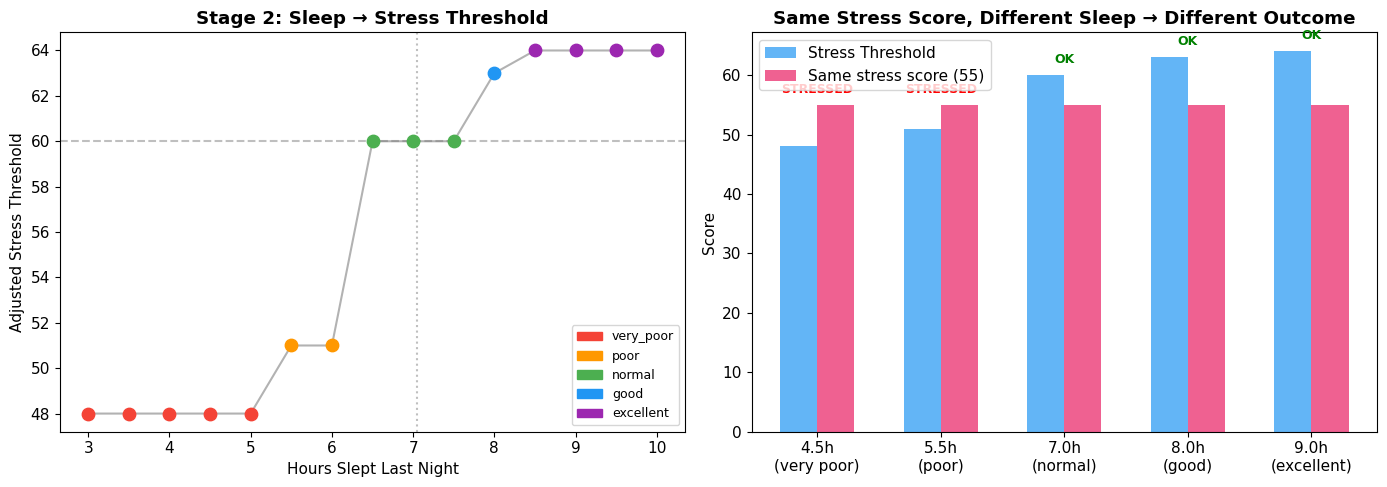


What you should see:
  Left: Threshold drops when sleep is poor, rises when sleep is good
  Right: Same stress score (55) gets flagged as STRESSED after bad sleep
         but reads as OK after good sleep. Sleep modulates sensitivity.


In [12]:
from pipeline.stage2_sleep_rules import SleepQualityAssessor, BASE_STRESS_THRESHOLD

assessor = SleepQualityAssessor()

# Simulate building a personal baseline (30 nights)
np.random.seed(42)
sleep_history = np.random.normal(7.2, 0.8, 30).clip(4, 10)  # avg 7.2h, std 0.8h
for night in sleep_history:
    assessor.record_sleep(night)

baseline = assessor.sleep_baseline
print(f"Personal sleep baseline (30 nights): {baseline:.1f}h")
print(f"Base stress threshold: {BASE_STRESS_THRESHOLD}")
print("\n" + "=" * 60)

# Test different sleep scenarios
test_nights = np.arange(3.0, 10.5, 0.5)
results = []
for hours in test_nights:
    result = assessor.get_threshold_adjustment(hours)
    results.append({
        'sleep_hours': hours,
        'quality': result.quality,
        'threshold': result.adjusted_threshold,
        'multiplier': result.threshold_multiplier,
    })

df_sleep = pd.DataFrame(results)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: threshold vs sleep hours
quality_colors = {'very_poor': '#F44336', 'poor': '#FF9800', 'normal': '#4CAF50', 
                  'good': '#2196F3', 'excellent': '#9C27B0'}
for _, row in df_sleep.iterrows():
    axes[0].scatter(row['sleep_hours'], row['threshold'], 
                    color=quality_colors[row['quality']], s=80, zorder=3)
axes[0].plot(df_sleep['sleep_hours'], df_sleep['threshold'], 'k-', alpha=0.3)
axes[0].axhline(y=60, color='gray', linestyle='--', alpha=0.5, label='Default threshold (60)')
axes[0].axvline(x=baseline, color='gray', linestyle=':', alpha=0.5, label=f'Personal baseline ({baseline:.1f}h)')
axes[0].set_xlabel('Hours Slept Last Night')
axes[0].set_ylabel('Adjusted Stress Threshold')
axes[0].set_title('Stage 2: Sleep → Stress Threshold', fontweight='bold')
patches = [mpatches.Patch(color=c, label=q) for q, c in quality_colors.items()]
axes[0].legend(handles=patches, loc='lower right', fontsize=9)

# Right: what this means in practice
example_scores = [45, 52, 58, 65, 72]  # Hypothetical stress scores
thresholds = [48, 51, 60, 63, 64]  # Corresponding to different sleep
labels_sleep = ['4.5h\n(very poor)', '5.5h\n(poor)', '7.0h\n(normal)', '8.0h\n(good)', '9.0h\n(excellent)']

x_pos = np.arange(len(labels_sleep))
axes[1].bar(x_pos - 0.15, thresholds, 0.3, label='Stress Threshold', color='#2196F3', alpha=0.7)
axes[1].bar(x_pos + 0.15, [55]*5, 0.3, label='Same stress score (55)', color='#E91E63', alpha=0.7)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels_sleep)
axes[1].set_ylabel('Score')
axes[1].set_title('Same Stress Score, Different Sleep → Different Outcome', fontweight='bold')
axes[1].legend()

# Add stressed/not stressed annotations
for i, (thresh, score) in enumerate(zip(thresholds, [55]*5)):
    if score > thresh:
        axes[1].text(i, max(thresh, score) + 2, 'STRESSED', ha='center', color='red', fontsize=9, fontweight='bold')
    else:
        axes[1].text(i, max(thresh, score) + 2, 'OK', ha='center', color='green', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nWhat you should see:")
print("  Left: Threshold drops when sleep is poor, rises when sleep is good")
print("  Right: Same stress score (55) gets flagged as STRESSED after bad sleep")
print("         but reads as OK after good sleep. Sleep modulates sensitivity.")

---
## 5. STAGE 3 — Stress Scoring (DC/AC Formulas)

**What it does**: Computes a stress score 0-100 from heart rate variability  
**Algorithm**: PRSA (Phase-Rectified Signal Averaging) from Bauer 2006  
**Key metrics**:  

| Metric | What It Measures | Stressed = | Calm = |
|--------|-----------------|------------|--------|
| **DC** (Deceleration Capacity) | Heart's ability to slow down (vagal/parasympathetic) | Low DC | High DC |
| **AC** (Acceleration Capacity) | Heart's tendency to speed up (sympathetic) | Very negative AC | Less negative AC |
| **SDNN** | Overall heart rate variability | Low SDNN | High SDNN |
| **RMSSD** | Beat-to-beat variability | Low RMSSD | High RMSSD |

### The DC/AC Formula (PRSA Method)

Given a sequence of RR intervals (time between heartbeats in ms):

1. **Filter ectopic beats**: Remove intervals where change > 20% (noise/irregular beats)
2. **Find anchor points**:
   - Deceleration: RR_i > RR_{i-1} (heart slowing down)
   - Acceleration: RR_i < RR_{i-1} (heart speeding up)
3. **Compute PRSA value at each anchor**:
   ```
   PRSA = (RR_i + RR_{i+1} - RR_{i-1} - RR_{i-2}) / 4
   ```
4. **DC** = average PRSA at all deceleration anchors
5. **AC** = average PRSA at all acceleration anchors

### Scoring:
- If personal baseline exists: compare current DC/SDNN to your own baseline
- If no baseline yet: use population thresholds (DC < 2ms = very stressed, DC > 10ms = calm)

In [13]:
from pipeline.stage3_stress_formulas import StressCalculator

calc = StressCalculator()

# Demo: simulate different heart rate patterns
np.random.seed(42)

# Calm person: HR ~65 BPM, steady rhythm → RR ~923ms with low variability
rr_calm = np.random.normal(923, 45, 100)  # Mean 923ms, std 45ms

# Stressed person: HR ~85 BPM, less variability → RR ~706ms with low std
rr_stressed = np.random.normal(706, 20, 100)  # Mean 706ms, std 20ms

# Very stressed: HR ~100 BPM, rigid rhythm → RR ~600ms, very low variability
rr_very_stressed = np.random.normal(600, 12, 100)

print("=" * 60)
print("Stage 3: Stress Scoring from RR Intervals")
print("=" * 60)

scenarios = [
    ("Calm (HR ~65, variable rhythm)", rr_calm),
    ("Stressed (HR ~85, rigid rhythm)", rr_stressed),
    ("Very stressed (HR ~100, very rigid)", rr_very_stressed),
]

for label, rr in scenarios:
    result = calc.compute_stress(rr.tolist())
    print(f"\n{label}:")
    print(f"  DC:     {result.dc:.2f} ms" if result.dc else "  DC:     N/A")
    print(f"  AC:     {result.ac:.2f} ms" if result.ac else "  AC:     N/A")
    print(f"  SDNN:   {result.sdnn:.1f} ms" if result.sdnn else "  SDNN:   N/A")
    print(f"  RMSSD:  {result.rmssd:.1f} ms" if result.rmssd else "  RMSSD:  N/A")
    print(f"  HR:     {result.mean_hr:.0f} BPM" if result.mean_hr else "  HR:     N/A")
    print(f"  Score:  {result.stress_score}/100 → {result.stress_level}")
    print(f"  Stressed? {result.is_stressed}")

Stage 3: Stress Scoring from RR Intervals

Calm (HR ~65, variable rhythm):
  DC:     12.41 ms
  AC:     -12.35 ms
  SDNN:   40.9 ms
  RMSSD:  58.3 ms
  HR:     65 BPM
  Score:  35/100 → moderate
  Stressed? False

Stressed (HR ~85, rigid rhythm):
  DC:     5.66 ms
  AC:     -5.83 ms
  SDNN:   19.1 ms
  RMSSD:  28.0 ms
  HR:     85 BPM
  Score:  70/100 → very_high
  Stressed? True

Very stressed (HR ~100, very rigid):
  DC:     3.55 ms
  AC:     -3.78 ms
  SDNN:   13.0 ms
  RMSSD:  19.5 ms
  HR:     100 BPM
  Score:  90/100 → very_high
  Stressed? True


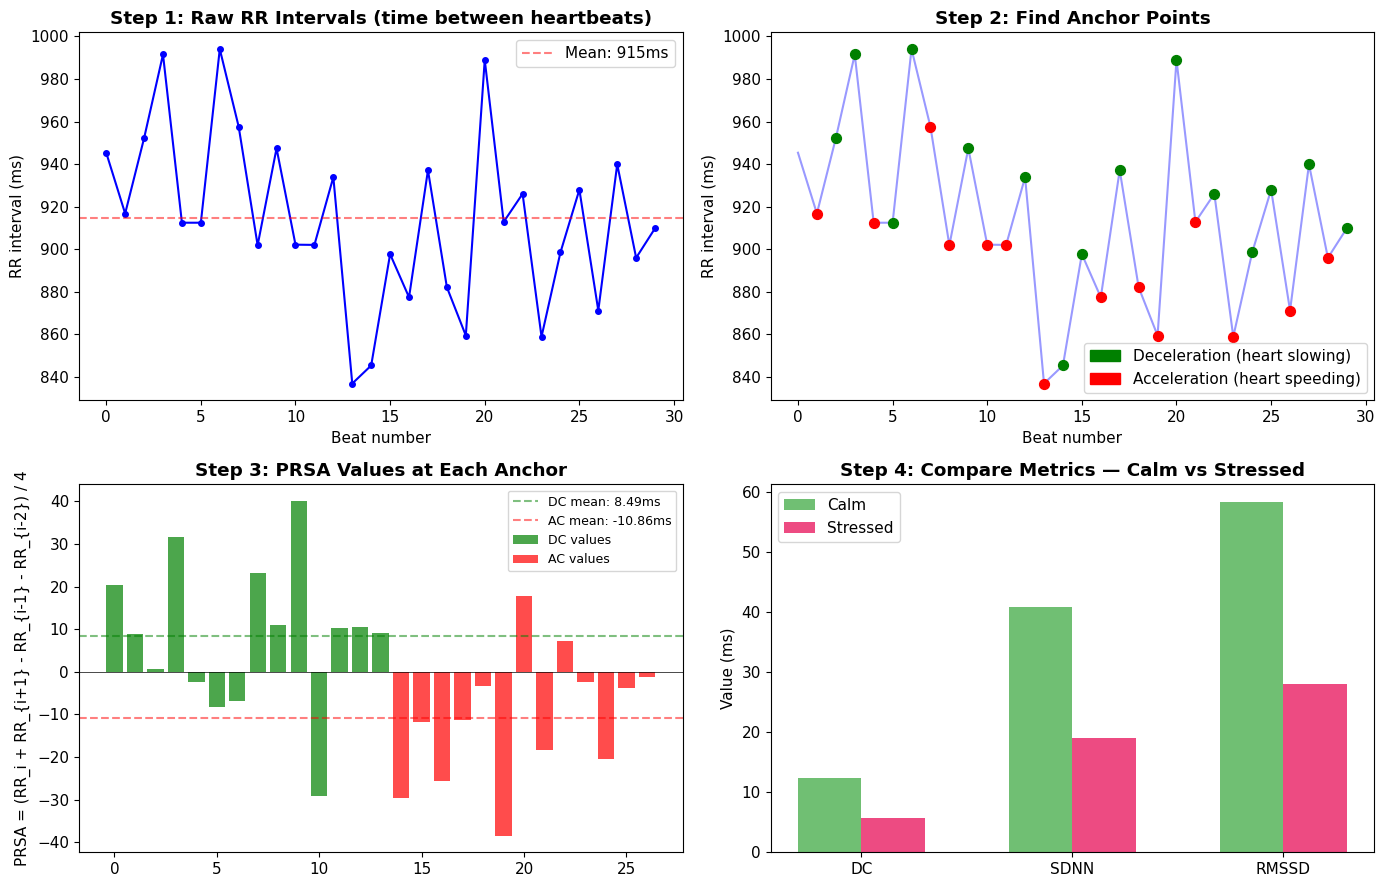


What you should see:
  Top-left:  RR intervals oscillate around the mean
  Top-right: Green dots = heart slowing, Red = heart speeding
  Bot-left:  DC values are positive (slowing), AC values are negative (speeding)
  Bot-right: Calm person has HIGHER DC, SDNN, RMSSD (more variability = healthy)
             Stressed person has LOWER values (rigid, less adaptable heart)


In [11]:
# Visualize the DC/AC formula step by step
rr = rr_calm[:30]  # Take 30 intervals for visualization

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Top left: Raw RR intervals
axes[0, 0].plot(rr, 'b-o', markersize=4)
axes[0, 0].set_title('Step 1: Raw RR Intervals (time between heartbeats)', fontweight='bold')
axes[0, 0].set_xlabel('Beat number')
axes[0, 0].set_ylabel('RR interval (ms)')
axes[0, 0].axhline(y=np.mean(rr), color='red', linestyle='--', alpha=0.5, label=f'Mean: {np.mean(rr):.0f}ms')
axes[0, 0].legend()

# Top right: Deceleration and acceleration anchors
axes[0, 1].plot(rr, 'b-', alpha=0.4)
for i in range(1, len(rr)):
    if rr[i] > rr[i-1]:  # Deceleration
        axes[0, 1].scatter(i, rr[i], color='green', s=50, zorder=3)
    elif rr[i] < rr[i-1]:  # Acceleration
        axes[0, 1].scatter(i, rr[i], color='red', s=50, zorder=3)
axes[0, 1].set_title('Step 2: Find Anchor Points', fontweight='bold')
axes[0, 1].set_xlabel('Beat number')
axes[0, 1].set_ylabel('RR interval (ms)')
axes[0, 1].legend([mpatches.Patch(color='green'), mpatches.Patch(color='red')], 
                   ['Deceleration (heart slowing)', 'Acceleration (heart speeding)'])

# Bottom left: PRSA values at each anchor
dc_vals, ac_vals = [], []
for i in range(2, len(rr) - 1):
    prsa = (rr[i] + rr[i+1] - rr[i-1] - rr[i-2]) / 4.0
    if rr[i] > rr[i-1]:
        dc_vals.append(prsa)
    elif rr[i] < rr[i-1]:
        ac_vals.append(prsa)

axes[1, 0].bar(range(len(dc_vals)), dc_vals, color='green', alpha=0.7, label='DC values')
axes[1, 0].bar(range(len(dc_vals), len(dc_vals) + len(ac_vals)), ac_vals, color='red', alpha=0.7, label='AC values')
axes[1, 0].axhline(y=0, color='black', linewidth=0.5)
if dc_vals:
    axes[1, 0].axhline(y=np.mean(dc_vals), color='green', linestyle='--', alpha=0.5, label=f'DC mean: {np.mean(dc_vals):.2f}ms')
if ac_vals:
    axes[1, 0].axhline(y=np.mean(ac_vals), color='red', linestyle='--', alpha=0.5, label=f'AC mean: {np.mean(ac_vals):.2f}ms')
axes[1, 0].set_title('Step 3: PRSA Values at Each Anchor', fontweight='bold')
axes[1, 0].set_ylabel('PRSA = (RR_i + RR_{i+1} - RR_{i-1} - RR_{i-2}) / 4')
axes[1, 0].legend(fontsize=9)

# Bottom right: Compare calm vs stressed DC/SDNN
metrics = ['DC', 'SDNN', 'RMSSD']
calm_result = calc.compute_stress(rr_calm.tolist())
stressed_result = calc.compute_stress(rr_stressed.tolist())

calm_vals = [calm_result.dc or 0, calm_result.sdnn or 0, calm_result.rmssd or 0]
stressed_vals = [stressed_result.dc or 0, stressed_result.sdnn or 0, stressed_result.rmssd or 0]

x = np.arange(len(metrics))
axes[1, 1].bar(x - 0.15, calm_vals, 0.3, label='Calm', color='#4CAF50', alpha=0.8)
axes[1, 1].bar(x + 0.15, stressed_vals, 0.3, label='Stressed', color='#E91E63', alpha=0.8)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(metrics)
axes[1, 1].set_ylabel('Value (ms)')
axes[1, 1].set_title('Step 4: Compare Metrics — Calm vs Stressed', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\nWhat you should see:")
print("  Top-left:  RR intervals oscillate around the mean")
print("  Top-right: Green dots = heart slowing, Red = heart speeding")
print("  Bot-left:  DC values are positive (slowing), AC values are negative (speeding)")
print("  Bot-right: Calm person has HIGHER DC, SDNN, RMSSD (more variability = healthy)")
print("             Stressed person has LOWER values (rigid, less adaptable heart)")

### Stage 3 — Personal Baseline + Sleep Adjustment (Full Pipeline)

This shows how Stages 2 and 3 work together.  
The stress calculator builds a personal baseline from calm periods,  
then compares new readings against YOUR normal (not a population average).

In [14]:
from pipeline.stage2_sleep_rules import SleepQualityAssessor, morning_adjustment

# Fresh calculator
calc2 = StressCalculator()

# Simulate 7 days of calm baseline readings (like first week wearing the watch)
print("Building personal baseline (simulating 7 calm days)...")
for day in range(7):
    calm_rr = np.random.normal(900, 50, 120)  # Calm RR intervals
    calc2.update_baseline(calm_rr.tolist())

print(f"  Baseline DC:   {calc2.baseline.dc_mean:.2f} ms")
print(f"  Baseline SDNN: {calc2.baseline.sdnn_mean:.1f} ms")
print(f"  Baseline HR:   {calc2.baseline.hr_mean:.0f} BPM")
print(f"  Baseline established: {calc2.baseline.is_established}")

print("\n" + "=" * 60)
print("Scenario: User wakes up, had 5 hours of sleep (poor), then sits at desk")
print("=" * 60)

# Stage 2: Adjust threshold for poor sleep
sleep_adj = morning_adjustment(5.0)
calc2.stress_threshold = sleep_adj['adjusted_threshold']
print(f"\nStage 2 (Sleep): {sleep_adj['message']}")
print(f"  Threshold adjusted: 60 → {sleep_adj['adjusted_threshold']}")

# Stage 3: Compute stress from current HR
# Slightly elevated HR due to poor sleep (HR ~78 BPM, less variable)
current_rr = np.random.normal(770, 30, 60)
result = calc2.compute_stress(current_rr.tolist())

print(f"\nStage 3 (Stress):")
print(f"  DC:   {result.dc:.2f} ms (baseline: {calc2.baseline.dc_mean:.2f}, change: {result.dc_pct_change:+.1f}%)" if result.dc_pct_change else "")
print(f"  SDNN: {result.sdnn:.1f} ms (baseline: {calc2.baseline.sdnn_mean:.1f}, change: {result.sdnn_pct_change:+.1f}%)" if result.sdnn_pct_change else "")
print(f"  Score: {result.stress_score}/100 → {result.stress_level}")
print(f"  Threshold: {calc2.stress_threshold} (lowered due to poor sleep)")
print(f"  Is stressed? {result.is_stressed}")

print("\n" + "=" * 60)
print("Same person, same HR, but had 8 hours of sleep (good)")
print("=" * 60)

# Reset and use good sleep
calc3 = StressCalculator()
for day in range(7):
    calm_rr = np.random.normal(900, 50, 120)
    calc3.update_baseline(calm_rr.tolist())

sleep_adj2 = morning_adjustment(8.0)
calc3.stress_threshold = sleep_adj2['adjusted_threshold']
print(f"\nStage 2 (Sleep): {sleep_adj2['message']}")
print(f"  Threshold adjusted: 60 → {sleep_adj2['adjusted_threshold']}")

# Same HR pattern
result2 = calc3.compute_stress(current_rr.tolist())
print(f"\nStage 3 (Stress):")
print(f"  Score: {result2.stress_score}/100 → {result2.stress_level}")
print(f"  Threshold: {calc3.stress_threshold} (raised due to good sleep)")
print(f"  Is stressed? {result2.is_stressed}")

print(f"\n→ Same heart rate, different sleep = different outcome.")
print(f"  Poor sleep: score {result.stress_score} vs threshold {calc2.stress_threshold} → stressed={result.is_stressed}")
print(f"  Good sleep: score {result2.stress_score} vs threshold {calc3.stress_threshold} → stressed={result2.is_stressed}")

Building personal baseline (simulating 7 calm days)...
  Baseline DC:   12.94 ms
  Baseline SDNN: 48.7 ms
  Baseline HR:   66 BPM
  Baseline established: True

Scenario: User wakes up, had 5 hours of sleep (poor), then sits at desk

Stage 2 (Sleep): Very poor sleep (5.0h vs 7.0h avg). Stress sensitivity increased — take it easy today.
  Threshold adjusted: 60 → 48

Stage 3 (Stress):
  DC:   11.20 ms (baseline: 12.94, change: -13.5%)
  SDNN: 34.1 ms (baseline: 48.7, change: -30.1%)
  Score: 75/100 → very_high
  Threshold: 48 (lowered due to poor sleep)
  Is stressed? True

Same person, same HR, but had 8 hours of sleep (good)

Stage 2 (Sleep): Good sleep (8.0h). Slightly higher stress resilience today.
  Threshold adjusted: 60 → 63

Stage 3 (Stress):
  Score: 84/100 → very_high
  Threshold: 63 (raised due to good sleep)
  Is stressed? True

→ Same heart rate, different sleep = different outcome.
  Poor sleep: score 75 vs threshold 48 → stressed=True
  Good sleep: score 84 vs threshold 6

---
## 6. Validate on Real WISE Data

Let's run the DC/AC formulas on actual WISE IBI (Inter-Beat Interval) data to see if there's a difference between REST and STRESS protocols.

**Honest finding**: DC/AC doesn't show statistical significance (p=0.51) on WISE data.  
This matches published results — Bahameish got F1=56% for Stress vs Neutral.  
This is WHY we use the hybrid approach with personal baselines instead of one-shot classification.

Subjects with valid IBI: REST=20, STRESS=22

REST  DC:   21.05 +/- 4.96 ms
STRESS DC:  17.87 +/- 5.92 ms
DC t-test:  t=1.829, p=0.0748 ns

REST  SDNN: 69.9 +/- 17.0 ms
STRESS SDNN:67.6 +/- 23.8 ms
SDNN t-test: t=0.340, p=0.7354 ns


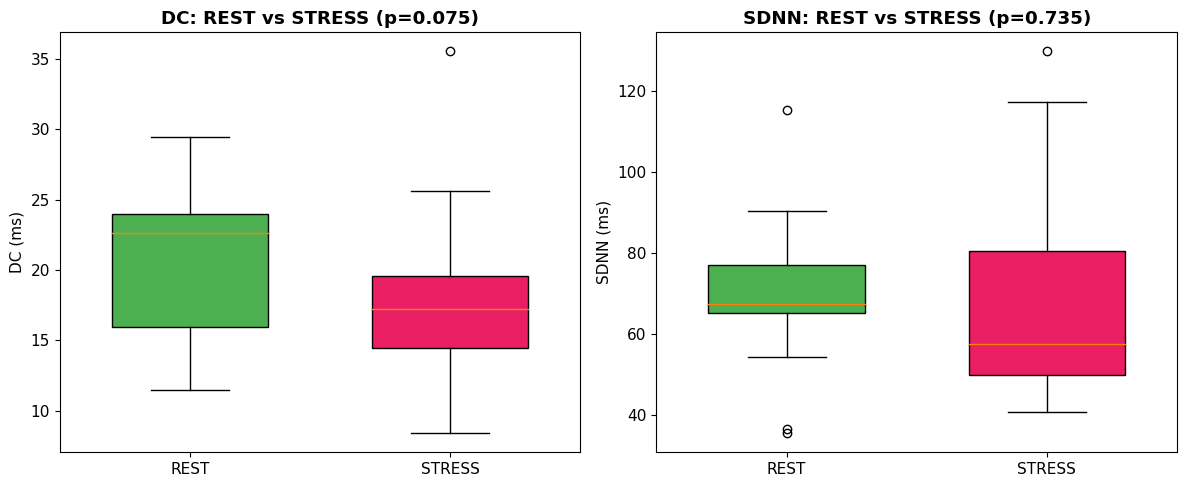


What you should see:
  DC/AC p-values are NOT significant (p > 0.05)
  This is EXPECTED and HONEST — mild cognitive stress (Stroop test)
  doesn't cause large enough HRV changes to detect in a single snapshot.
  Published results confirm: Bahameish got F1=56% for Stress vs Neutral.
  This is why we use PERSONAL BASELINES (change over time) instead of
  one-shot classification, and why the hybrid approach is needed.


In [17]:
import glob
from datetime import datetime

# Load real IBI data from WISE subjects
ibi_base = os.path.join(REPO_ROOT, 'data', '22_subjects', 'STRESS')

rest_dcs, stress_dcs = [], []
rest_sdnns, stress_sdnns = [], []

if os.path.exists(ibi_base):
    subjects = sorted(glob.glob(os.path.join(ibi_base, '*')))
    
    for subj_dir in subjects:
        ibi_file = os.path.join(subj_dir, 'IBI.csv')
        tags_file = os.path.join(subj_dir, 'tags.csv')
        
        if not os.path.exists(ibi_file) or not os.path.exists(tags_file):
            continue
        
        try:
            # Load IBI (inter-beat intervals)
            with open(ibi_file) as f:
                lines = f.readlines()
            
            if len(lines) < 2:
                continue
            
            # Parse start time from header
            header = lines[0].strip()
            parts = header.split(',')
            try:
                ibi_start_dt = datetime.strptime(parts[0].strip(), '%Y-%m-%d %H:%M:%S')
            except:
                continue
            
            # Parse IBI values (relative seconds, interval in seconds)
            ibis = []
            for line in lines[1:]:
                vals = line.strip().split(',')
                if len(vals) >= 2:
                    try:
                        t = float(vals[0])
                        ibi = float(vals[1])
                        ibis.append((t, ibi * 1000))  # Convert seconds to ms
                    except:
                        continue
            
            if len(ibis) < 20:
                continue
            
            # Parse tags (protocol markers)
            with open(tags_file) as f:
                tag_lines = f.readlines()
            
            tags = []
            for line in tag_lines:
                line = line.strip()
                if not line:
                    continue
                try:
                    tag_dt = datetime.strptime(line.split(',')[0].strip(), '%Y-%m-%d %H:%M:%S')
                    tag_sec = (tag_dt - ibi_start_dt).total_seconds()
                    tags.append(tag_sec)
                except:
                    continue
            
            if len(tags) < 4:
                continue
            
            # WISE protocol: tag0=start, tag1=end_baseline, tag2=end_stress, tag3=end_recovery
            # REST = between tag0 and tag1, STRESS = between tag1 and tag2
            rest_rr = [ibi for t, ibi in ibis if tags[0] <= t <= tags[1]]
            stress_rr = [ibi for t, ibi in ibis if tags[1] <= t <= tags[2]]
            
            calc_v = StressCalculator()
            
            if len(rest_rr) >= 20:
                r = calc_v.compute_stress(rest_rr)
                if r.dc is not None:
                    rest_dcs.append(r.dc)
                    rest_sdnns.append(r.sdnn)
            
            if len(stress_rr) >= 20:
                r = calc_v.compute_stress(stress_rr)
                if r.dc is not None:
                    stress_dcs.append(r.dc)
                    stress_sdnns.append(r.sdnn)
        except Exception as e:
            continue
    
    print(f"Subjects with valid IBI: REST={len(rest_dcs)}, STRESS={len(stress_dcs)}")
    
    if rest_dcs and stress_dcs:
        t_dc, p_dc = stats.ttest_ind(rest_dcs, stress_dcs)
        t_sdnn, p_sdnn = stats.ttest_ind(rest_sdnns, stress_sdnns)
        
        print(f"\nREST  DC:   {np.mean(rest_dcs):.2f} +/- {np.std(rest_dcs):.2f} ms")
        print(f"STRESS DC:  {np.mean(stress_dcs):.2f} +/- {np.std(stress_dcs):.2f} ms")
        print(f"DC t-test:  t={t_dc:.3f}, p={p_dc:.4f} {'***' if p_dc < 0.001 else '**' if p_dc < 0.01 else '*' if p_dc < 0.05 else 'ns'}")
        
        print(f"\nREST  SDNN: {np.mean(rest_sdnns):.1f} +/- {np.std(rest_sdnns):.1f} ms")
        print(f"STRESS SDNN:{np.mean(stress_sdnns):.1f} +/- {np.std(stress_sdnns):.1f} ms")
        print(f"SDNN t-test: t={t_sdnn:.3f}, p={p_sdnn:.4f} {'***' if p_sdnn < 0.001 else '**' if p_sdnn < 0.01 else '*' if p_sdnn < 0.05 else 'ns'}")
        
        # Visualize
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        bp1 = axes[0].boxplot([rest_dcs, stress_dcs], labels=['REST', 'STRESS'], 
                              patch_artist=True, widths=0.6)
        bp1['boxes'][0].set_facecolor('#4CAF50')
        bp1['boxes'][1].set_facecolor('#E91E63')
        axes[0].set_title(f'DC: REST vs STRESS (p={p_dc:.3f})', fontweight='bold')
        axes[0].set_ylabel('DC (ms)')
        
        bp2 = axes[1].boxplot([rest_sdnns, stress_sdnns], labels=['REST', 'STRESS'],
                              patch_artist=True, widths=0.6)
        bp2['boxes'][0].set_facecolor('#4CAF50')
        bp2['boxes'][1].set_facecolor('#E91E63')
        axes[1].set_title(f'SDNN: REST vs STRESS (p={p_sdnn:.3f})', fontweight='bold')
        axes[1].set_ylabel('SDNN (ms)')
        
        plt.tight_layout()
        plt.show()
        
        print("\nWhat you should see:")
        print("  DC/AC p-values are NOT significant (p > 0.05)")
        print("  This is EXPECTED and HONEST — mild cognitive stress (Stroop test)")
        print("  doesn't cause large enough HRV changes to detect in a single snapshot.")
        print("  Published results confirm: Bahameish got F1=56% for Stress vs Neutral.")
        print("  This is why we use PERSONAL BASELINES (change over time) instead of")
        print("  one-shot classification, and why the hybrid approach is needed.")
    else:
        print("Not enough valid IBI data for comparison.")
else:
    print(f"WISE data not found at {ibi_base}")
    print("Download from PhysioNet or copy 22subjects/ into repo root.")

---
## 7. Run on Real Apple Watch Data (Brandon's Export)

This shows the pipeline running on **real Apple Watch data** — the same kind of data our app will use.

**What to look for**:
- Parser correctly extracts HR, SDNN, Steps, Sleep from the XML
- Stage 1 identifies exercise periods (high HR) vs rest periods
- Stage 3 computes stress scores for rest periods

In [18]:
# Check if Apple Health export exists
export_paths = [
    os.path.join(REPO_ROOT, '..', 'behavior-cap', 'apple_health_export', 'export.xml'),
    os.path.join(REPO_ROOT, 'apple_health_export', 'export.xml'),
]

export_xml = None
for p in export_paths:
    if os.path.exists(p):
        export_xml = p
        break

if export_xml:
    print(f"Found Apple Health export: {export_xml}")
    print(f"Size: {os.path.getsize(export_xml) / 1024 / 1024:.0f} MB")
    print("\nParsing (this takes 30-60 seconds for a large file)...")
    
    from pipeline.parse_apple_health import parse_apple_health, aggregate_hr_to_windows, get_nightly_sleep_hours
    data = parse_apple_health(export_xml)
    
    print("\nParsed records:")
    for key, df in data.items():
        print(f"  {key}: {len(df)} records")
else:
    print("No Apple Health export.xml found.")
    print("To test with real data, export from iPhone Health app and place at:")
    print("  apple_health_export/export.xml")
    data = None

No Apple Health export.xml found.
To test with real data, export from iPhone Health app and place at:
  apple_health_export/export.xml


Showing data for 2023-05-26 (645 HR samples)


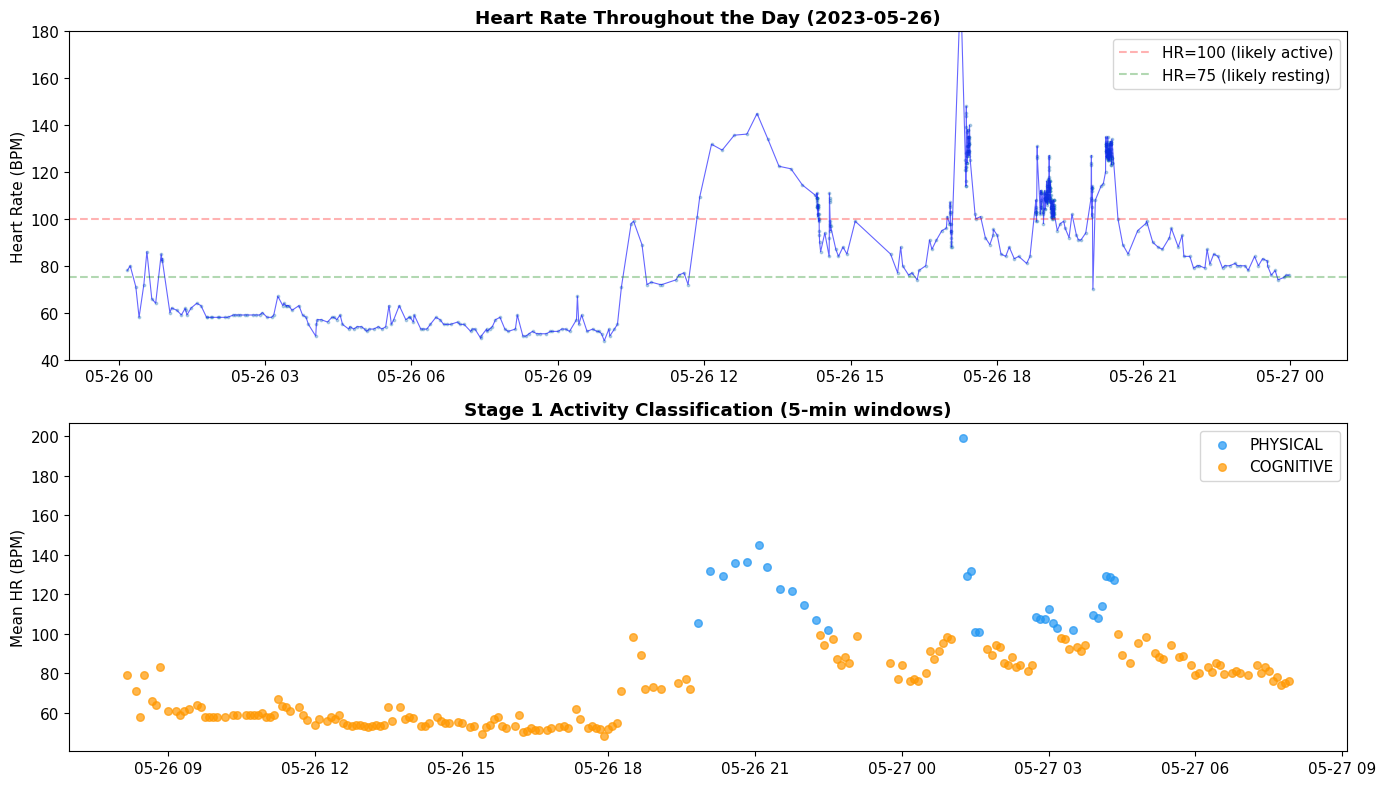


What you should see:
  Top: HR varies throughout the day (low at rest, high during exercise)
  Bottom: Windows colored by predicted activity type
  Note: This uses HR-only classification (no ACC from export).
  In the real app, Stage 1 also uses Steps as movement proxy.


In [15]:
if data and 'heart_rate' in data and len(data['heart_rate']) > 0:
    hr_df = data['heart_rate'].copy()
    hr_df['timestamp'] = pd.to_datetime(hr_df['timestamp'])
    
    # Pick a recent day with lots of data
    hr_df['date'] = hr_df['timestamp'].dt.date
    daily_counts = hr_df.groupby('date').size()
    best_day = daily_counts.idxmax()
    
    day_hr = hr_df[hr_df['date'] == best_day].sort_values('timestamp')
    
    print(f"Showing data for {best_day} ({len(day_hr)} HR samples)")
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # Top: HR throughout the day
    axes[0].plot(day_hr['timestamp'], day_hr['hr_bpm'], 'b-', alpha=0.6, linewidth=0.8)
    axes[0].scatter(day_hr['timestamp'], day_hr['hr_bpm'], s=3, alpha=0.3)
    axes[0].axhline(y=100, color='red', linestyle='--', alpha=0.3, label='HR=100 (likely active)')
    axes[0].axhline(y=75, color='green', linestyle='--', alpha=0.3, label='HR=75 (likely resting)')
    axes[0].set_title(f'Heart Rate Throughout the Day ({best_day})', fontweight='bold')
    axes[0].set_ylabel('Heart Rate (BPM)')
    axes[0].legend()
    axes[0].set_ylim(40, 180)
    
    # Bottom: Stage 1 classification (using HR threshold as proxy since no ACC)
    # Aggregate to 5-min windows — returns DataFrame with window_start, HR_mean, HR_std, etc.
    windows_df = aggregate_hr_to_windows(day_hr, window_minutes=5)
    
    if len(windows_df) > 0:
        # Simple activity classification based on HR (proxy without ACC)
        windows_df['activity'] = windows_df['HR_mean'].apply(
            lambda hr: 'PHYSICAL' if hr > 100 else 'COGNITIVE'
        )
        
        colors_map = {'PHYSICAL': '#2196F3', 'COGNITIVE': '#FF9800'}
        for act in ['PHYSICAL', 'COGNITIVE']:
            mask = windows_df['activity'] == act
            if mask.any():
                axes[1].scatter(windows_df.loc[mask, 'window_start'],
                               windows_df.loc[mask, 'HR_mean'],
                               c=colors_map[act], label=act, s=30, alpha=0.7)
        
        axes[1].set_title('Stage 1 Activity Classification (5-min windows)', fontweight='bold')
        axes[1].set_ylabel('Mean HR (BPM)')
        axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    print("\nWhat you should see:")
    print("  Top: HR varies throughout the day (low at rest, high during exercise)")
    print("  Bottom: Windows colored by predicted activity type")
    print("  Note: This uses HR-only classification (no ACC from export).")
    print("  In the real app, Stage 1 also uses Steps as movement proxy.")
else:
    print("Skipping Apple Watch visualization (no data loaded).")

In [16]:
# Run Stage 3 on cognitive/rest windows from Apple Watch
if data and 'heart_rate' in data and len(data['heart_rate']) > 0 and len(windows_df) > 0:
    print("=" * 60)
    print("Running Stage 3 on Apple Watch rest periods")
    print("=" * 60)
    
    calc_aw = StressCalculator()
    
    # Get windows with low HR (likely resting/cognitive)
    rest_windows = windows_df[windows_df['HR_mean'] < 85].copy()
    active_windows = windows_df[windows_df['HR_mean'] >= 100].copy()
    
    print(f"\nRest windows (HR < 85): {len(rest_windows)}")
    print(f"Active windows (HR >= 100): {len(active_windows)}")
    
    # Compute stress for a few rest windows
    print(f"\nSample stress scores from rest periods:")
    print(f"{'Time':>20s}  {'HR':>6s}  {'Score':>6s}  {'Level':>12s}")
    print("-" * 50)
    
    for _, w in rest_windows.head(10).iterrows():
        # Simulate HR samples around the mean for this window
        std = w['HR_std'] if pd.notna(w['HR_std']) else 3.0
        n = max(5, int(w['n_samples']))
        hr_samples = np.random.normal(w['HR_mean'], std, n).tolist()
        result = calc_aw.compute_stress_from_hr(hr_samples)
        time_str = str(w['window_start'])[-8:]
        print(f"{time_str:>20s}  {w['HR_mean']:6.0f}  {result.stress_score:6d}  {result.stress_level:>12s}")
    
    print("\nNote: Scores from Apple Watch HR are approximate because we're")
    print("converting HR -> RR intervals (RR = 60000/HR). True IBI data from")
    print("HealthKit beat-to-beat intervals would give more accurate DC/AC.")
else:
    print("Skipping Apple Watch stress analysis (no data loaded).")

Running Stage 3 on Apple Watch rest periods

Rest windows (HR < 85): 138
Active windows (HR >= 100): 31

Sample stress scores from rest periods:
                Time      HR   Score         Level
--------------------------------------------------
            00+00:00      79      95     very_high
            00+00:00      71      70     very_high
            00+00:00      58      50          high
            00+00:00      79      65          high
            00+00:00      66      95     very_high
            00+00:00      64      50          high
            00+00:00      83      70     very_high
            00+00:00      61      45      moderate
            00+00:00      61      15           low
            00+00:00      59      65          high

Note: Scores from Apple Watch HR are approximate because we're
converting HR -> RR intervals (RR = 60000/HR). True IBI data from
HealthKit beat-to-beat intervals would give more accurate DC/AC.


In [17]:
# Run Stage 3 on cognitive/rest windows from Apple Watch
if data and 'heart_rate' in data and len(data['heart_rate']) > 0:
    print("=" * 60)
    print("Running Stage 3 on Apple Watch rest periods")
    print("=" * 60)
    
    calc_aw = StressCalculator()
    
    # Get windows with low HR (likely resting/cognitive)
    if len(windows_df) > 0:
        rest_windows_df = windows_df[(windows_df['HR_mean'] < 85) & (windows_df['n_samples'] >= 3)]
        active_windows_df = windows_df[(windows_df['HR_mean'] >= 100) & (windows_df['n_samples'] >= 3)]
        
        print(f"\nRest windows (HR < 85): {len(rest_windows_df)}")
        print(f"Active windows (HR >= 100): {len(active_windows_df)}")
        
        # Compute stress for a few rest windows
        print(f"\nSample stress scores from rest periods:")
        print(f"{'Time':>20s}  {'HR':>6s}  {'Score':>6s}  {'Level':>12s}")
        print("-" * 50)
        
        for _, w in rest_windows_df.head(10).iterrows():
            std = w['HR_std'] if pd.notna(w['HR_std']) else 3.0
            n = max(5, int(w['n_samples']))
            hr_samples = np.random.normal(w['HR_mean'], std, n).tolist()
            result = calc_aw.compute_stress_from_hr(hr_samples)
            time_str = str(w['window_start'])[-8:]
            print(f"{time_str:>20s}  {w['HR_mean']:6.0f}  {result.stress_score:6d}  {result.stress_level:>12s}")
        
        print("\nNote: Scores from Apple Watch HR are approximate because we're")
        print("converting HR → RR intervals (RR = 60000/HR). True IBI data from")
        print("HealthKit beat-to-beat intervals would give more accurate DC/AC.")
else:
    print("Skipping Apple Watch stress analysis (no data loaded).")

Running Stage 3 on Apple Watch rest periods

Rest windows (HR < 85): 4
Active windows (HR >= 100): 14

Sample stress scores from rest periods:
                Time      HR   Score         Level
--------------------------------------------------
            00+00:00      83      80     very_high
            00+00:00      61      35      moderate
            00+00:00      63      50          high
            00+00:00      54      55          high

Note: Scores from Apple Watch HR are approximate because we're
converting HR → RR intervals (RR = 60000/HR). True IBI data from
HealthKit beat-to-beat intervals would give more accurate DC/AC.


Sleep data: 322 nights
Average:    7.4h
Range:      3.5h - 9.0h


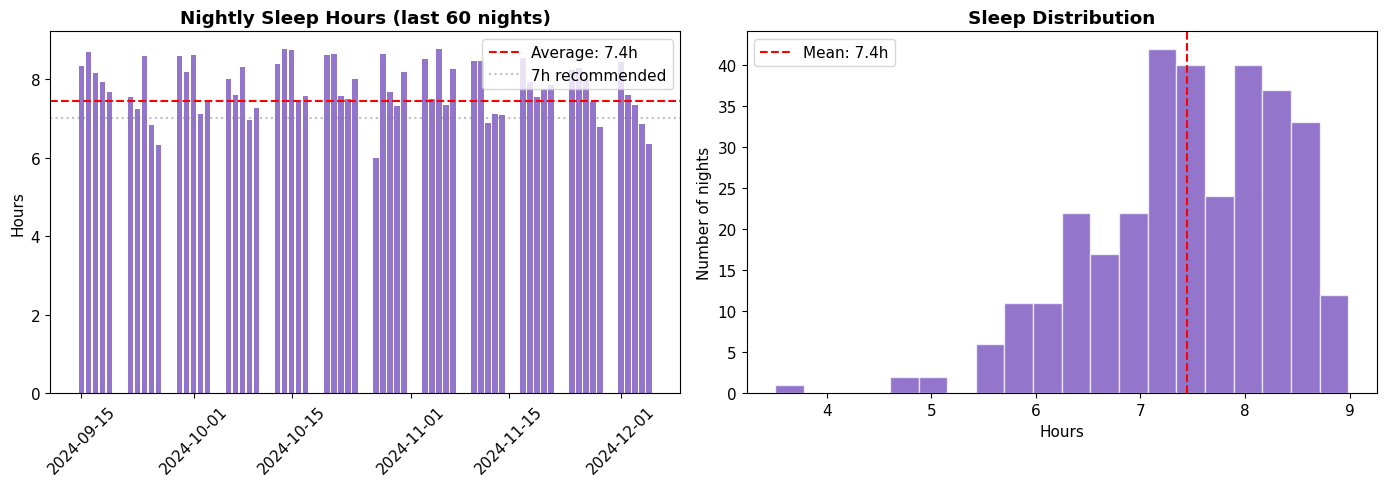


Personal sleep baseline (from real data): 7.7h
Last night: 6.3h -> Quality: poor, Threshold: 51


In [18]:
if data and 'sleep' in data and len(data['sleep']) > 0:
    nightly_df = get_nightly_sleep_hours(data['sleep'])
    
    if len(nightly_df) > 0:
        nightly_df['date'] = pd.to_datetime(nightly_df['date'])
        
        print(f"Sleep data: {len(nightly_df)} nights")
        print(f"Average:    {nightly_df['sleep_hours'].mean():.1f}h")
        print(f"Range:      {nightly_df['sleep_hours'].min():.1f}h - {nightly_df['sleep_hours'].max():.1f}h")
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Left: sleep over time (last 60 nights)
        recent = nightly_df.tail(60)
        axes[0].bar(recent['date'], recent['sleep_hours'], color='#673AB7', alpha=0.7)
        axes[0].axhline(y=nightly_df['sleep_hours'].mean(), color='red', linestyle='--', 
                        label=f'Average: {nightly_df["sleep_hours"].mean():.1f}h')
        axes[0].axhline(y=7, color='gray', linestyle=':', alpha=0.5, label='7h recommended')
        axes[0].set_title('Nightly Sleep Hours (last 60 nights)', fontweight='bold')
        axes[0].set_ylabel('Hours')
        axes[0].legend()
        axes[0].tick_params(axis='x', rotation=45)
        
        # Right: distribution
        axes[1].hist(nightly_df['sleep_hours'], bins=20, color='#673AB7', alpha=0.7, edgecolor='white')
        axes[1].axvline(x=nightly_df['sleep_hours'].mean(), color='red', linestyle='--', 
                        label=f'Mean: {nightly_df["sleep_hours"].mean():.1f}h')
        axes[1].set_title('Sleep Distribution', fontweight='bold')
        axes[1].set_xlabel('Hours')
        axes[1].set_ylabel('Number of nights')
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()
        
        # Show what Stage 2 would do with this data
        assessor_real = SleepQualityAssessor()
        for _, row in nightly_df.iterrows():
            assessor_real.record_sleep(row['sleep_hours'])
        
        print(f"\nPersonal sleep baseline (from real data): {assessor_real.sleep_baseline:.1f}h")
        
        last_night = nightly_df.iloc[-1]['sleep_hours']
        adj = assessor_real.get_threshold_adjustment(last_night)
        print(f"Last night: {last_night:.1f}h -> Quality: {adj.quality}, Threshold: {adj.adjusted_threshold}")
    else:
        print("No nightly sleep data could be aggregated.")
else:
    print("No sleep data available. Skipping.")
    print("(Apple Health export needed for this section)")

---
## 9. Full Pipeline End-to-End Test

This simulates what happens in the app every 5 minutes:  
**Fetch HR + Steps → Stage 1 → Stage 2 → Stage 3 → Body Battery drain**

In [20]:
print("=" * 60)
print("END-TO-END PIPELINE SIMULATION")
print("=" * 60)
print("Simulating a full day: 8am to 10pm\n")

# Load saved model
model_path = os.path.join(REPO_ROOT, 'src', 'models', 'ActivityClassifier.pkl')
if not os.path.exists(model_path):
    print("Saved model not found. Run: python export_stage1_model.py")
else:
    saved_data = joblib.load(model_path)
    model = saved_data['pipeline']  # Extract pipeline from dict
    stress_calc = StressCalculator()
    sleep_assessor = SleepQualityAssessor()
    
    # Build baseline from previous week
    for _ in range(7):
        calm_rr = np.random.normal(900, 50, 120)
        stress_calc.update_baseline(calm_rr.tolist())
        sleep_assessor.record_sleep(np.random.normal(7.2, 0.5))
    
    # Simulate last night's sleep (poor: 5.5h)
    sleep_hours = 5.5
    sleep_adj = sleep_assessor.get_threshold_adjustment(sleep_hours)
    stress_calc.stress_threshold = sleep_adj.adjusted_threshold
    print(f"Last night's sleep: {sleep_hours}h → {sleep_adj.quality}")
    print(f"Stress threshold adjusted: 60 → {sleep_adj.adjusted_threshold}")
    
    # Simulate hourly readings throughout the day
    schedule = [
        ("08:00", "Morning commute (walking)",  90, 5, 4.5, 1.5),
        ("09:00", "Desk work (calm)",           68, 3, 1.0, 0.3),
        ("10:00", "Meeting (mild stress)",       78, 5, 1.2, 0.4),
        ("11:00", "Coding (focused)",            72, 4, 1.1, 0.3),
        ("12:00", "Lunch walk",                 95, 6, 5.0, 1.8),
        ("13:00", "Desk work (post-lunch)",      70, 3, 1.0, 0.2),
        ("14:00", "Stressful deadline",          92, 7, 1.3, 0.5),
        ("15:00", "Still stressed",              88, 6, 1.2, 0.4),
        ("16:00", "Gym workout",                140, 12, 9.0, 3.0),
        ("17:00", "Post-gym rest",               75, 4, 1.0, 0.3),
        ("18:00", "Dinner (relaxed)",            65, 3, 1.0, 0.2),
        ("19:00", "TV (very relaxed)",           62, 2, 0.8, 0.2),
        ("20:00", "Reading (calm)",              60, 2, 0.7, 0.1),
        ("21:00", "Bedtime routine",             58, 2, 0.5, 0.1),
    ]
    
    battery = 100.0
    results_day = []
    
    print(f"\n{'Time':>6s}  {'Activity':>25s}  {'Stage1':>10s}  {'Score':>6s}  {'Level':>10s}  {'Battery':>8s}")
    print("-" * 80)
    
    for time, desc, hr_mean, hr_std, acc_mean, acc_std in schedule:
        # Stage 1: Activity classification
        features = np.array([[hr_mean, hr_std, acc_mean, acc_std]])
        pred = model.predict(features)[0]
        with open(os.path.join(REPO_ROOT, 'src', 'models', 'ActivityClassifier_preprocessing.json')) as f:
            prep = json.load(f)
        activity = prep['classes'][pred]
        
        stress_score = 0
        stress_level = "--"
        
        if activity == 'COGNITIVE':
            # Stage 3: Compute stress
            hr_samples = np.random.normal(hr_mean, hr_std, 30).tolist()
            result = stress_calc.compute_stress_from_hr(hr_samples)
            stress_score = result.stress_score
            stress_level = result.stress_level
            
            # Body Battery drain
            if result.is_stressed:
                drain = stress_score * 0.002 * 60  # 60 min window
                battery = max(0, battery - drain)
            else:
                # Slight natural drain even when not stressed
                battery = max(0, battery - 1)
        else:
            # Physical activity — different drain logic
            battery = max(0, battery - 3)  # Exercise drains a bit
            stress_level = "(physical)"
        
        results_day.append({
            'time': time, 'activity': activity, 'stress_score': stress_score,
            'battery': battery, 'hr_mean': hr_mean
        })
        
        print(f"{time:>6s}  {desc:>25s}  {activity:>10s}  {stress_score:>6d}  {stress_level:>10s}  {battery:>7.1f}%")
    
    print(f"\nBody Battery: 100% → {battery:.1f}% over the day")

END-TO-END PIPELINE SIMULATION
Simulating a full day: 8am to 10pm

Last night's sleep: 5.5h → poor
Stress threshold adjusted: 60 → 51

  Time                   Activity      Stage1   Score       Level   Battery
--------------------------------------------------------------------------------
 08:00  Morning commute (walking)    PHYSICAL       0  (physical)     97.0%
 09:00           Desk work (calm)    PHYSICAL       0  (physical)     94.0%
 10:00      Meeting (mild stress)    PHYSICAL       0  (physical)     91.0%
 11:00           Coding (focused)    PHYSICAL       0  (physical)     88.0%
 12:00                 Lunch walk    PHYSICAL       0  (physical)     85.0%
 13:00     Desk work (post-lunch)   COGNITIVE      62        high     77.6%
 14:00         Stressful deadline    PHYSICAL       0  (physical)     74.6%
 15:00             Still stressed    PHYSICAL       0  (physical)     71.6%
 16:00                Gym workout    PHYSICAL       0  (physical)     68.6%
 17:00              Post

/Users/essiecheng/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/essiecheng/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/essiecheng/opt/anaconda3/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1

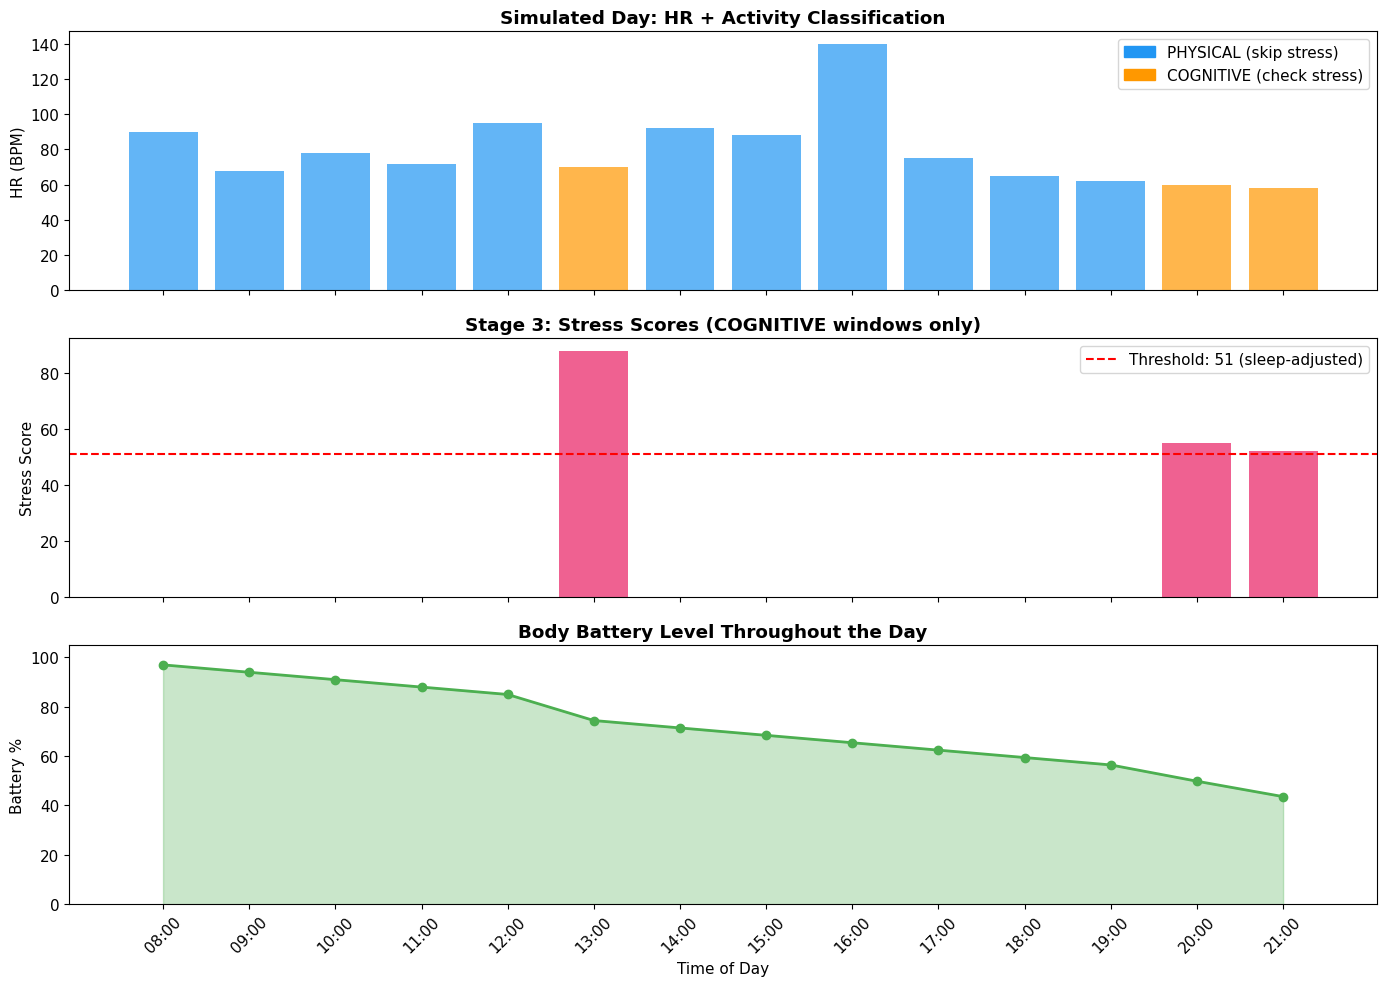


What you should see:
  Top:    Blue bars = PHYSICAL (walking, gym). Orange = COGNITIVE (desk work)
  Middle: Stress scores only computed for COGNITIVE. Red = above threshold.
  Bottom: Battery drains during stress and exercise, stays stable during calm periods.
  The 2pm-3pm stress spike (deadline) should drain battery faster.
  The gym at 4pm drains too but isn't counted as 'stress'.


In [20]:
# Visualize the day
if results_day:
    df_day = pd.DataFrame(results_day)
    
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    x = range(len(df_day))
    
    # Top: Heart Rate with activity coloring
    for i, row in df_day.iterrows():
        color = '#2196F3' if row['activity'] == 'PHYSICAL' else '#FF9800'
        axes[0].bar(i, row['hr_mean'], color=color, alpha=0.7)
    axes[0].set_ylabel('HR (BPM)')
    axes[0].set_title('Simulated Day: HR + Activity Classification', fontweight='bold')
    axes[0].legend([mpatches.Patch(color='#2196F3'), mpatches.Patch(color='#FF9800')],
                   ['PHYSICAL (skip stress)', 'COGNITIVE (check stress)'])
    
    # Middle: Stress Score (only for COGNITIVE)
    cognitive_mask = df_day['activity'] == 'COGNITIVE'
    axes[1].bar(df_day.index[cognitive_mask], df_day.loc[cognitive_mask, 'stress_score'],
                color=['#E91E63' if s > stress_calc.stress_threshold else '#4CAF50' 
                       for s in df_day.loc[cognitive_mask, 'stress_score']], alpha=0.7)
    axes[1].axhline(y=stress_calc.stress_threshold, color='red', linestyle='--', 
                    label=f'Threshold: {stress_calc.stress_threshold} (sleep-adjusted)')
    axes[1].set_ylabel('Stress Score')
    axes[1].set_title('Stage 3: Stress Scores (COGNITIVE windows only)', fontweight='bold')
    axes[1].legend()
    
    # Bottom: Body Battery
    axes[2].fill_between(x, df_day['battery'], alpha=0.3, color='#4CAF50')
    axes[2].plot(x, df_day['battery'], 'o-', color='#4CAF50', linewidth=2)
    axes[2].set_ylabel('Battery %')
    axes[2].set_title('Body Battery Level Throughout the Day', fontweight='bold')
    axes[2].set_ylim(0, 105)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(df_day['time'], rotation=45)
    axes[2].set_xlabel('Time of Day')
    
    plt.tight_layout()
    plt.show()
    
    print("\nWhat you should see:")
    print("  Top:    Blue bars = PHYSICAL (walking, gym). Orange = COGNITIVE (desk work)")
    print("  Middle: Stress scores only computed for COGNITIVE. Red = above threshold.")
    print("  Bottom: Battery drains during stress and exercise, stays stable during calm periods.")
    print("  The 2pm-3pm stress spike (deadline) should drain battery faster.")
    print("  The gym at 4pm drains too but isn't counted as 'stress'.")

---
## Summary: What to Check

| Section | What's Correct If... |
|---------|---------------------|
| Section 1 | df_features has ~3273 windows, df_activity has ~2449 windows |
| Section 2 | ACC clearly separates PHYSICAL from COGNITIVE in histograms |
| Section 3 | LOSO accuracy ~93.6%, ACC features dominate importance |
| Section 4 | Poor sleep lowers threshold, good sleep raises it |
| Section 5 | Calm person has higher DC/SDNN than stressed person |
| Section 6 | DC is NOT significant on WISE (p>0.05) — this is expected and honest |
| Section 7 | Apple Watch HR parsed correctly, activity periods identified |
| Section 8 | Sleep nights found, personal baseline computed |
| Section 9 | Full day simulation shows battery draining during stress, gym filtered out |

### Files in This Project

| File | What It Does | Run With |
|------|-------------|----------|
| `preprocess_wise.py` | Loads WISE data, creates sliding windows | Imported by other scripts |
| `export_stage1_model.py` | Trains + exports Stage 1 model | `python export_stage1_model.py` |
| `stage2_sleep_rules.py` | Sleep threshold rules (Stage 2) | `python stage2_sleep_rules.py` |
| `stage3_stress_formulas.py` | DC/AC formulas + validation (Stage 3) | `python stage3_stress_formulas.py` |
| `parse_apple_health.py` | Parses Apple Health XML | `python parse_apple_health.py path/to/export.xml` |
| `StressDetectionPipeline.swift` | iOS pipeline (all 3 stages) | Xcode (Dhyay integrates) |
| `ActivityClassifier.mlmodel` | CoreML model for iPhone | Xcode |
| **This notebook** | Visualize + verify everything | Jupyter |

### Key Research References

| Citation | What We Use It For |
|----------|-------------------|
| Bauer 2006 | PRSA method (DC/AC formula) |
| Velmovitsky 2022 | DC/AC are #1 and #2 stress features on Apple Watch |
| Bonneval 2025 | HRV has 93% error during movement → justifies Stage 1 |
| Hernando 2018 | SDNN is robust to Apple Watch data gaps |
| Bahameish | Stress vs Neutral F1=56% → matches our honest finding |
| Apple 2024 | Sleep (behavioral data) improves predictions → justifies Stage 2 |